## Estudio resolucion temporal

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import display, HTML
import time
import pickle
import os
import sys
import csv

In [24]:
def run_simulation(nx=50, ny=50):
    # Parámetros adimensionales
    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    Lx_star, Ly_star = 1.0, 1.0
    dx_star = Lx_star / (nx - 1)
    dy_star = Ly_star / (ny - 1)

    
    CFL_target = 0.008
    u_max = 1.0  # velocidad máxima esperada
    dt_star = CFL_target * dx_star / u_max
    nt = int(1.0 / dt_star)  # número de pasos para llegar a t*=1.0

    up, u0 = -0.5, 1.0
    T0_star, T1_star = 0.0, 0.0

    x_star = np.linspace(0, Lx_star, nx)
    y_star = np.linspace(0, Ly_star, ny)
    X_star, Y_star = np.meshgrid(x_star, y_star)

    u_star = np.zeros((ny, nx)) + u0
    v_star = np.zeros((ny, nx))
    p_star = np.zeros((ny, nx))
    T_star = np.zeros((ny, nx)) + T1_star

    # Condiciones de frontera
    u_star[0, :] = up
    u_star[-1, :] = u0
    v_star[0, :] = v_star[-1, :] = 0
    T_star[0, :] = T0_star
    T_star[-1, :] = T1_star

    u_history, v_history, p_history, T_history, tau_history = [], [], [], [], []

    for n in range(nt):
        u_old, v_old, p_old, T_old = u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy()
        
        for i in range(1, ny-1):
            for j in range(1, nx-1):
                conv_u_x = u_old[i,j] * (u_old[i,j+1] - u_old[i,j-1]) / (2*dx_star)
                conv_u_y = v_old[i,j] * (u_old[i+1,j] - u_old[i-1,j]) / (2*dy_star)
                diff_u_x = (u_old[i,j+1] - 2*u_old[i,j] + u_old[i,j-1]) / dx_star**2
                diff_u_y = (u_old[i+1,j] - 2*u_old[i,j] + u_old[i-1,j]) / dy_star**2
                grad_p_x = 0  # omitido
                u_star[i,j] += dt_star * (-conv_u_x - conv_u_y - Eu * grad_p_x + (1/Re)*(diff_u_x + diff_u_y))

                conv_v_x = u_old[i,j] * (v_old[i,j+1] - v_old[i,j-1]) / (2*dx_star)
                conv_v_y = v_old[i,j] * (v_old[i+1,j] - v_old[i-1,j]) / (2*dy_star)
                diff_v_x = (v_old[i,j+1] - 2*v_old[i,j] + v_old[i,j-1]) / dx_star**2
                diff_v_y = (v_old[i+1,j] - 2*v_old[i,j] + v_old[i-1,j]) / dy_star**2
                grad_p_y = (p_old[i+1,j] - p_old[i-1,j]) / (2*dy_star)
                v_star[i,j] += dt_star * (-conv_v_x - conv_v_y - Eu * grad_p_y + (1/Re)*(diff_v_x + diff_v_y))

        for _ in range(20):
            for i in range(1, ny-1):
                for j in range(1, nx-1):
                    p_star[i,j] = 0.25 * (p_old[i+1,j] + p_old[i-1,j] + p_old[i,j+1] + p_old[i,j-1] - 
                                          (dx_star*dy_star)/(2*(dx_star**2 + dy_star**2)) * (
                                              (u_star[i,j+1] - u_star[i,j-1])/(2*dx_star) + 
                                              (v_star[i+1,j] - v_star[i-1,j])/(2*dy_star)))

        for i in range(1, ny-1):
            for j in range(1, nx-1):
                u_star[i,j] -= dt_star * Eu * (p_star[i,j+1] - p_star[i,j-1])/(2*dx_star)
                v_star[i,j] -= dt_star * Eu * (p_star[i+1,j] - p_star[i-1,j])/(2*dy_star)

        for i in range(1, ny-1):
            for j in range(1, nx-1):
                conv_T_x = u_star[i,j] * (T_old[i,j+1] - T_old[i,j-1])/(2*dx_star)
                conv_T_y = v_star[i,j] * (T_old[i+1,j] - T_old[i-1,j])/(2*dy_star)
                diff_T_x = (T_old[i,j+1] - 2*T_old[i,j] + T_old[i,j-1])/(dx_star**2)
                diff_T_y = (T_old[i+1,j] - 2*T_old[i,j] + T_old[i-1,j])/(dy_star**2)
                Sxx = (u_star[i,j+1] - u_star[i,j-1])/(2*dx_star)
                Syy = (v_star[i+1,j] - v_star[i-1,j])/(2*dy_star)
                Sxy = 0.5*((u_star[i+1,j] - u_star[i-1,j])/(2*dy_star) + 
                           (v_star[i,j+1] - v_star[i,j-1])/(2*dx_star))
                viscous_heating = (Ec/Re)*(2*(Sxx**2 + Syy**2) + 4*Sxy**2)
                T_star[i,j] += dt_star * (-conv_T_x - conv_T_y + 
                                          (1/(Re*Pr))*(diff_T_x + diff_T_y) + 
                                          viscous_heating)

        tau = np.zeros((ny, nx))
        for i in range(1, ny-1):
            for j in range(nx):
                tau[i,j] = (u_star[i+1,j] - u_star[i-1,j])/(2*dy_star)

        # Condiciones de frontera
        v_star[:, -1] = 0
        u_star[-1, :] = u0
        u_star[0, :] = up
        v_star[0, :] = v_star[-1, :] = 0
        u_star[:, -1] = u_star[:, -2]
        p_star[:, 0] = p_star[:, 1]
        p_star[:, -1] = p_star[:, -2]
        p_star[0, :] = p_star[1, :]
        p_star[-1, :] = p_star[-2, :]
        if n % 10 == 0:
                    print(f"\rSimulación en progreso: paso {n}/{nt}", end="")
                    sys.stdout.flush()
                    u_history.append(u_star.copy())
                    v_history.append(v_star.copy())
                    p_history.append(p_star.copy())
                    T_history.append(T_star.copy())
                    tau_history.append(tau.copy())
    print("\rSimulación finalizada.                      ")

    return {
        "u_history": u_history,
        "v_history": v_history,
        "p_history": p_history,
        "T_history": T_history,
        "tau_history": tau_history,
        "params": {"nx": nx, "ny": ny, "dt_star": dt_star, "nt": nt},
        "X_star": X_star,
        "Y_star": Y_star
    }

In [31]:
def animar_resultados_linea(sim_data, vel_level=0.9, temp_level=0.01):
    X_star = sim_data["X_star"]
    Y_star = sim_data["Y_star"]
    u_hist = sim_data["u_history"]
    v_hist = sim_data["v_history"]
    p_hist = sim_data["p_history"]
    T_hist = sim_data["T_history"]
    tau_hist = sim_data["tau_history"]
    dt_star = sim_data["params"]["dt_star"]

    dt_star_visual = 10 * dt_star
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 8))

    text1 = ax1.text(0.02, 0.95, '', transform=ax1.transAxes, fontsize=9, color='white',
                     bbox=dict(facecolor='black', alpha=0.5))
    text2 = ax2.text(0.02, 0.95, '', transform=ax2.transAxes, fontsize=9, color='white',
                     bbox=dict(facecolor='black', alpha=0.5))

    def interp_crossing(y, field, level):
        for i in range(len(field) - 1):
            f1, f2 = field[i], field[i+1]
            if (f1 < level and f2 > level) or (f1 > level and f2 < level):
                dy = y[i+1] - y[i]
                df = f2 - f1
                return y[i] + (level - f1) * dy / df
        return None

    def y_on_line_at_x(line_points, x_target):
        tol = 0.01
        x_vals, y_vals = line_points[:, 0], line_points[:, 1]
        close_idx = np.where(np.abs(x_vals - x_target) < tol)[0]
        if len(close_idx) == 0:
            return None
        return float(np.max(y_vals[close_idx]))

    linea_temp_plot, = ax2.plot([], [], 'k', linewidth=1.5)

    def update(frame):
        speed = np.sqrt(u_hist[frame]**2 + v_hist[frame]**2)

        for ax in [ax1, ax2, ax3, ax4]:
            while ax.collections:
                ax.collections[-1].remove()

        ax1.contourf(X_star, Y_star, speed, levels=20, cmap='jet')
        ax1.contour(X_star, Y_star, speed, levels=[vel_level], colors='k', linewidths=1.5)

        cs = ax2.contour(X_star, Y_star, T_hist[frame], levels=[temp_level], colors='k', linewidths=1.5)
        selected_line = None
        if cs.allsegs and len(cs.allsegs[0]) > 0:
            selected_line = np.concatenate(cs.allsegs[0])
            linea_temp_plot.set_data(selected_line[:, 0], selected_line[:, 1])
        else:
            linea_temp_plot.set_data([], [])

        ax2.contourf(X_star, Y_star, T_hist[frame], levels=20, cmap='jet')
        ax3.contourf(X_star, Y_star, p_hist[frame], levels=20, cmap='viridis')
        ax4.contourf(X_star, Y_star, tau_hist[frame], levels=20, cmap='coolwarm')

        t_star = frame * dt_star_visual
        ax1.set_title(f'Velocidad |u*| (t*={t_star:.2f})')
        ax2.set_title(f'Temperatura T* (t*={t_star:.2f})')
        ax3.set_title(f'Presión p* (t*={t_star:.2f})')
        ax4.set_title(f'Shear stress τ* (t*={t_star:.2f})')

        y80 = y_on_line_at_x(selected_line, 0.80) if selected_line is not None else None
        y95 = y_on_line_at_x(selected_line, 0.95) if selected_line is not None else None

        y80_str = f"{y80:.4f}" if y80 is not None else "No definido"
        y95_str = f"{y95:.4f}" if y95 is not None else "No definido"
        text2.set_text(f'Línea T* en x=0.80: {y80_str}\nLínea T* en x=0.95: {y95_str}')

        x_index = np.argmin(np.abs(X_star[0] - 1.0))
        y_col = Y_star[:, x_index]
        u_col = np.sqrt(u_hist[frame][:, x_index]**2 + v_hist[frame][:, x_index]**2)
        y_vel = interp_crossing(y_col, u_col, vel_level)
        y_vel_str = f"{y_vel:.4f}" if y_vel is not None else "No definido"
        text1.set_text(f'y* @ x=1 donde |u*|={vel_level}:\n{y_vel_str}')

        if frame == len(u_hist) - 1:
            print(f"\nt* = {t_star:.3f}")
            print(f"  |u*|={vel_level} @ x=1 → y* = {y_vel_str}")
            print(f"  Línea T* @ x=0.80 → y* = {y80_str}")
            print(f"  Línea T* @ x=0.95 → y* = {y95_str}")

        return ax1.collections + ax2.collections + ax3.collections + ax4.collections + [text1, text2, linea_temp_plot]

    # Primer fotograma
    speed = np.sqrt(u_hist[0]**2 + v_hist[0]**2)
    ax1.contourf(X_star, Y_star, speed, levels=20, cmap='jet')
    ax1.contour(X_star, Y_star, speed, levels=[vel_level], colors='k', linewidths=1.5)

    cs0 = ax2.contour(X_star, Y_star, T_hist[0], levels=[temp_level], colors='k', linewidths=1.5)
    if cs0.allsegs and len(cs0.allsegs[0]) > 0:
        selected_line0 = np.concatenate(cs0.allsegs[0])
        linea_temp_plot.set_data(selected_line0[:, 0], selected_line0[:, 1])
    else:
        linea_temp_plot.set_data([], [])

    ax2.contourf(X_star, Y_star, T_hist[0], levels=20, cmap='jet')
    ax3.contourf(X_star, Y_star, p_hist[0], levels=20, cmap='viridis')
    ax4.contourf(X_star, Y_star, tau_hist[0], levels=20, cmap='coolwarm')

    fig.suptitle(f"Simulación con resolución {X_star.shape[1]}x{Y_star.shape[0]}, CFL fija", fontsize=14)
    plt.tight_layout()

    anim = FuncAnimation(fig, update, frames=len(u_hist), interval=100, blit=False)
    return anim, fig


## Boundary layer

In [26]:
def calcular_boundary_layer_thickness(u, y, u0=1.0):
    perfil = u[:, u.shape[1] // 2]
    for i in range(len(perfil)):
        if perfil[i] >= 0.99 * u0:
            return y[i]
    return y[-1]


## Mean pressure coeficient

In [27]:
def calcular_coeficiente_presion_medio(p):
    return np.mean(p[:, 0])  # en la pared izquierda


## Max temperature 

In [28]:
def calcular_temperatura_maxima(T):
    return np.max(T)



🔧 Ejecutando simulación para 25x25...
Simulación finalizada.                      
✅ Datos guardados en CFL_8e-3/25x25.pkl

t* = 0.997
  |u*|=0.9 @ x=1 → y* = 0.3200
  Línea T* @ x=0.80 → y* = 0.4837
  Línea T* @ x=0.95 → y* = 0.5100
🎞️ Animación guardada en CFL_8e-3/25x25.mp4

🔧 Ejecutando simulación para 50x50...
Simulación finalizada.                      
✅ Datos guardados en CFL_8e-3/50x50.pkl

t* = 0.999
  |u*|=0.9 @ x=1 → y* = 0.2943
  Línea T* @ x=0.80 → y* = 0.4847
  Línea T* @ x=0.95 → y* = 0.4898
🎞️ Animación guardada en CFL_8e-3/50x50.mp4

🔧 Ejecutando simulación para 100x100...
Simulación finalizada.                      
✅ Datos guardados en CFL_8e-3/100x100.pkl

t* = 1.000
  |u*|=0.9 @ x=1 → y* = 0.2814
  Línea T* @ x=0.80 → y* = 0.4965
  Línea T* @ x=0.95 → y* = 0.5019
🎞️ Animación guardada en CFL_8e-3/100x100.mp4


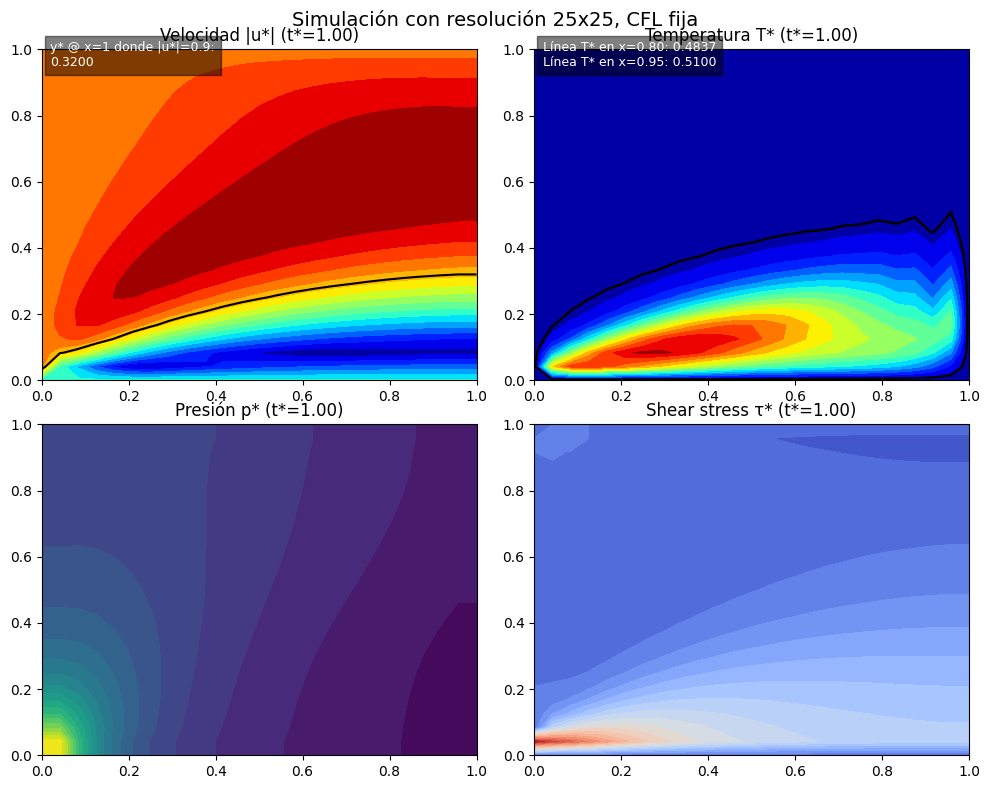

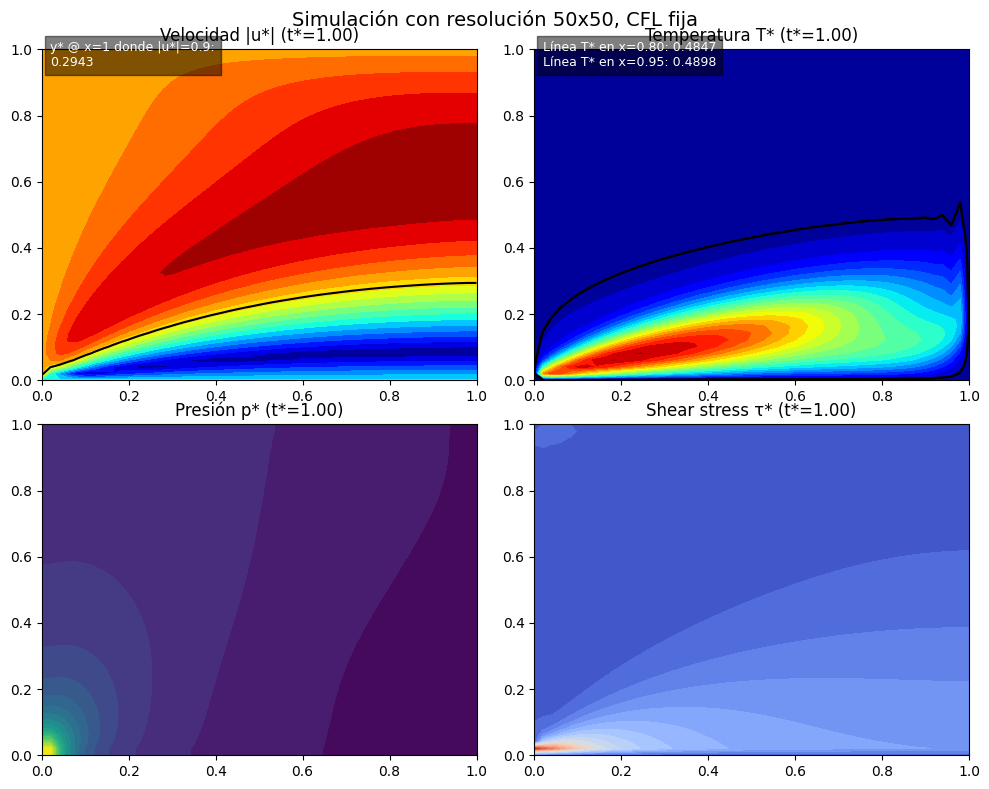

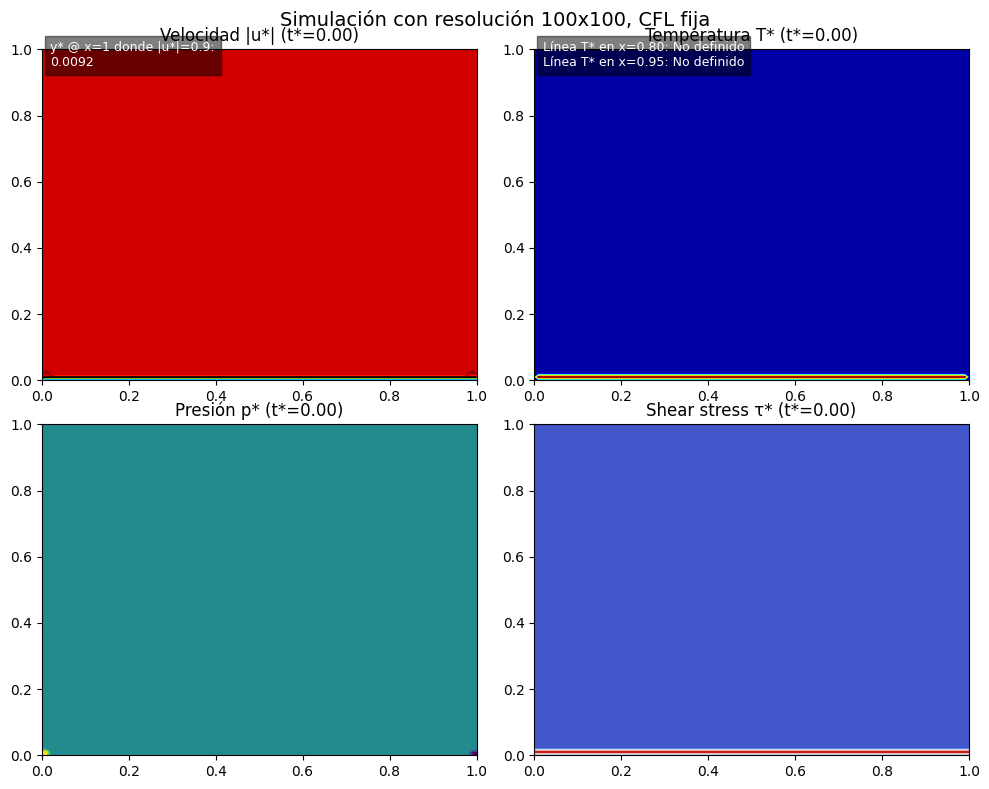

In [32]:
# Lista de resoluciones a simular
resoluciones = [(25, 25), (50, 50), (100, 100)]
output_folder = "CFL_8e-3"

# Crear carpeta si no existe
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

for nx, ny in resoluciones:
    print(f"\n🔧 Ejecutando simulación para {nx}x{ny}...")
    
    # Ejecutar simulación
    sim = run_simulation(nx, ny)

    # Guardar datos .pkl
    nombre_base = f"{nx}x{ny}"
    archivo_pkl = os.path.join(output_folder, f"{nombre_base}.pkl")
    with open(archivo_pkl, 'wb') as f:
        pickle.dump(sim, f)
    print(f"✅ Datos guardados en {archivo_pkl}")

    # Crear animación
    anim, fig = animar_resultados_linea(sim)
    archivo_mp4 = os.path.join(output_folder, f"{nombre_base}.mp4")
    writer = FFMpegWriter(fps=10, metadata={'title': f"Simulación {nombre_base}"})
    anim.save(archivo_mp4, writer=writer)
    print(f"🎞️ Animación guardada en {archivo_mp4}")
